Caso 1: Telecomunicaciones CallMeMaybe
Objetivo: Identificar operadores ineficaces del servicio de telefonía virtual  

Paso 1 - Carga y exploración de datos


In [253]:
#importar librerías 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from statsmodels.stats.proportion import proportions_ztest


In [254]:
# cargar datasets
clients = pd.read_csv(r'C:\Users\mateg\Documents\triple_ten\final_project_da\case1_telecom\data\raw\telecom_clients.csv')
telecom_new = pd.read_csv(r'C:\Users\mateg\Documents\triple_ten\final_project_da\case1_telecom\data\raw\telecom_dataset_new.csv')


1.1 Dataset clients - exploración

In [255]:
# Revisión de estructura, tipo de datos y valores ausentes
clients.shape

(732, 3)

In [256]:
clients.info()

<class 'pandas.DataFrame'>
RangeIndex: 732 entries, 0 to 731
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   user_id      732 non-null    int64
 1   tariff_plan  732 non-null    str  
 2   date_start   732 non-null    str  
dtypes: int64(1), str(2)
memory usage: 17.3 KB


In [257]:
clients.head()

,user_id,tariff_plan,date_start
0,166713,A,2019-08-15
1,166901,A,2019-08-23
2,168527,A,2019-10-29
3,167097,A,2019-09-01
4,168193,A,2019-10-16


1.2 Dataset telecom_new - exploración

In [258]:
telecom_new.shape

(53902, 9)

In [259]:
telecom_new.info()

<class 'pandas.DataFrame'>
RangeIndex: 53902 entries, 0 to 53901
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   user_id              53902 non-null  int64  
 1   date                 53902 non-null  str    
 2   direction            53902 non-null  str    
 3   internal             53785 non-null  object 
 4   operator_id          45730 non-null  float64
 5   is_missed_call       53902 non-null  bool   
 6   calls_count          53902 non-null  int64  
 7   call_duration        53902 non-null  int64  
 8   total_call_duration  53902 non-null  int64  
dtypes: bool(1), float64(1), int64(4), object(1), str(2)
memory usage: 3.3+ MB


In [260]:
telecom_new.head()

,user_id,date,direction,internal,operator_id,is_missed_call,calls_count,call_duration,total_call_duration
0,166377,2019-08-04 00:00:00+03:00,in,False,NaN,True,2,0,4
1,166377,2019-08-05 00:00:00+03:00,out,True,880022.0,True,3,0,5
2,166377,2019-08-05 00:00:00+03:00,out,True,880020.0,True,1,0,1
3,166377,2019-08-05 00:00:00+03:00,out,True,880020.0,False,1,10,18
4,166377,2019-08-05 00:00:00+03:00,out,False,880022.0,True,3,0,25


In [261]:
telecom_new.describe()

,user_id,operator_id,calls_count,call_duration,total_call_duration
count,53902.000000,45730.000000,53902.000000,53902.000000,53902.000000
mean,167295.344477,916535.993002,16.451245,866.684427,1157.133297
std,598.883775,21254.123136,62.917170,3731.791202,4403.468763
min,166377.000000,879896.000000,1.000000,0.000000,0.000000
25%,166782.000000,900788.000000,1.000000,0.000000,47.000000
50%,167162.000000,913938.000000,4.000000,38.000000,210.000000
75%,167819.000000,937708.000000,12.000000,572.000000,902.000000
max,168606.000000,973286.000000,4817.000000,144395.000000,166155.000000


Paso 2 - Limpieza de datos

2.1 Manejo de valores nulos 

In [262]:

# Conversión de nulos y type de la columna 'internal' del DF 

telecom_new['internal'] = telecom_new['internal'].fillna(False).astype('bool')

In [263]:
# verificación de conversión de nulos
telecom_new.info()

<class 'pandas.DataFrame'>
RangeIndex: 53902 entries, 0 to 53901
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   user_id              53902 non-null  int64  
 1   date                 53902 non-null  str    
 2   direction            53902 non-null  str    
 3   internal             53902 non-null  bool   
 4   operator_id          45730 non-null  float64
 5   is_missed_call       53902 non-null  bool   
 6   calls_count          53902 non-null  int64  
 7   call_duration        53902 non-null  int64  
 8   total_call_duration  53902 non-null  int64  
dtypes: bool(2), float64(1), int64(4), str(2)
memory usage: 3.0 MB


2.2 Correción del tipo de datos

In [264]:
# modificación de dtype de 'operator_id' a Int64
telecom_new['operator_id']=telecom_new['operator_id'].astype('Int64')

In [265]:
# modificación de dtype de 'date' a pd.to_datetime

telecom_new['date'] = pd.to_datetime(telecom_new['date'])

In [266]:
# modificación de dtype de 'date_start' a pd.to_datetime

clients['date_start'] = pd.to_datetime(clients['date_start'])

In [267]:
clients['tariff_plan']=clients['tariff_plan'].astype('category')

In [268]:
# Verificación de los anteriores cambios
clients.info()

<class 'pandas.DataFrame'>
RangeIndex: 732 entries, 0 to 731
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   user_id      732 non-null    int64         
 1   tariff_plan  732 non-null    category      
 2   date_start   732 non-null    datetime64[us]
dtypes: category(1), datetime64[us](1), int64(1)
memory usage: 12.3 KB


In [269]:
# verificación de los anteriores cambios
telecom_new.info()

<class 'pandas.DataFrame'>
RangeIndex: 53902 entries, 0 to 53901
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype                    
---  ------               --------------  -----                    
 0   user_id              53902 non-null  int64                    
 1   date                 53902 non-null  datetime64[us, UTC+03:00]
 2   direction            53902 non-null  str                      
 3   internal             53902 non-null  bool                     
 4   operator_id          45730 non-null  Int64                    
 5   is_missed_call       53902 non-null  bool                     
 6   calls_count          53902 non-null  int64                    
 7   call_duration        53902 non-null  int64                    
 8   total_call_duration  53902 non-null  int64                    
dtypes: Int64(1), bool(2), datetime64[us, UTC+03:00](1), int64(4), str(1)
memory usage: 3.0 MB


2.3 Verificación y eliminación de duplicados

In [270]:
# verificación de duplicados en dataset clients
clients.duplicated().sum()

np.int64(0)

In [271]:
# verificación de duplicados en dataset telecom_new
telecom_new.duplicated().sum()

np.int64(4900)

In [272]:
telecom_new[telecom_new.duplicated(keep=False)].head()

,user_id,date,direction,internal,operator_id,is_missed_call,calls_count,call_duration,total_call_duration
6,166377,2019-08-05 00:00:00+03:00,out,False,880020,True,8,0,50
8,166377,2019-08-05 00:00:00+03:00,out,False,880020,True,8,0,50
27,166377,2019-08-12 00:00:00+03:00,in,False,<NA>,True,2,0,34
28,166377,2019-08-12 00:00:00+03:00,in,False,<NA>,True,2,0,34
38,166377,2019-08-14 00:00:00+03:00,in,False,<NA>,True,1,0,3


In [273]:
telecom_new = telecom_new.drop_duplicates()

In [274]:
telecom_new.duplicated().sum()

np.int64(0)

Paso 3 - Integración de datos (MERGE)

In [275]:
# union de datasets
telecom_full = telecom_new.merge(clients, on='user_id', how='left')

In [276]:
# comprobación de número de filas
len(telecom_new), len(telecom_full)

(49002, 49002)

In [277]:
# comprobación de duplicados
clients['user_id'].duplicated().sum()

np.int64(0)

In [278]:
# verificación del merge()
telecom_full.head()

,user_id,date,direction,internal,operator_id,is_missed_call,calls_count,call_duration,total_call_duration,tariff_plan,date_start
0,166377,2019-08-04 00:00:00+03:00,in,False,<NA>,True,2,0,4,B,2019-08-01
1,166377,2019-08-05 00:00:00+03:00,out,True,880022,True,3,0,5,B,2019-08-01
2,166377,2019-08-05 00:00:00+03:00,out,True,880020,True,1,0,1,B,2019-08-01
3,166377,2019-08-05 00:00:00+03:00,out,True,880020,False,1,10,18,B,2019-08-01
4,166377,2019-08-05 00:00:00+03:00,out,False,880022,True,3,0,25,B,2019-08-01


Paso 4 - Análisis Exploratorio (EDA)

4.1 Distribuciones de variables clave

a. Análisis de: calls_count, call_duration, total_call_duration

In [279]:
# resumen descriptivo de las llamadas
telecom_full[['calls_count', 'call_duration', 'total_call_duration']].describe()

,calls_count,call_duration,total_call_duration
count,49002.000000,49002.000000,49002.000000
mean,16.462777,866.282091,1156.558202
std,63.604098,3775.503352,4451.473661
min,1.000000,0.000000,0.000000
25%,1.000000,0.000000,46.000000
50%,4.000000,37.000000,208.000000
75%,12.000000,570.000000,901.000000
max,4817.000000,144395.000000,166155.000000


Inicio analizando la variable call_duration (duración de llamdas)

pero antes, convertiré las unidades de segundos a minutos tanto en call_duration como en total_call_duration para facilidad de interpretación.

In [280]:
# call_duration:  convierto a minutos
telecom_full['call_duration_min'] = telecom_full['call_duration'] / 60

# total_call_duration:  convierto a minutos 
telecom_full['total_call_duration_min'] = telecom_full['total_call_duration'] / 60

In [281]:
# verifico el cambio de segundo a minutos 
telecom_full[['calls_count', 'call_duration_min', 'total_call_duration_min']].describe().round(0)

,calls_count,call_duration_min,total_call_duration_min
count,49002.0,49002.0,49002.0
mean,16.0,14.0,19.0
std,64.0,63.0,74.0
min,1.0,0.0,0.0
25%,1.0,0.0,1.0
50%,4.0,1.0,3.0
75%,12.0,10.0,15.0
max,4817.0,2407.0,2769.0


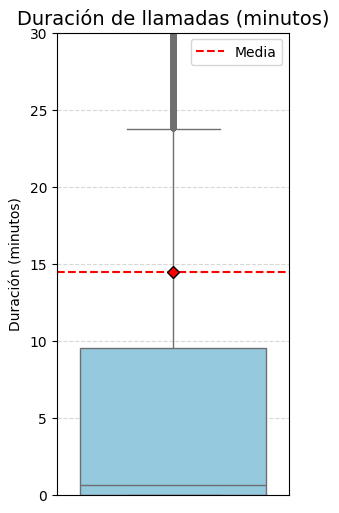

In [282]:
# análisis boxplot de la duración de llamdas(call_duration_min)--full

plt.figure(figsize=(3,6))

sns.boxplot(
    y='call_duration_min',
    data=telecom_full,
    color='skyblue',
    fliersize=3,
    showmeans=True,
    meanprops={
        "marker": "D",
        "markerfacecolor": "red",
        "markeredgecolor": "black",
        "markersize": 6
    }
)
mean_val = telecom_full['call_duration_min'].mean()
plt.axhline(mean_val, color='red', linestyle='--', label='Media')
plt.legend()

# Limitar eje Y para enfocarse en valores típicos
plt.ylim(0, 30)  

plt.title('Duración de llamadas (minutos)', fontsize=14)
plt.ylabel('Duración (minutos)')
plt.xticks([])
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

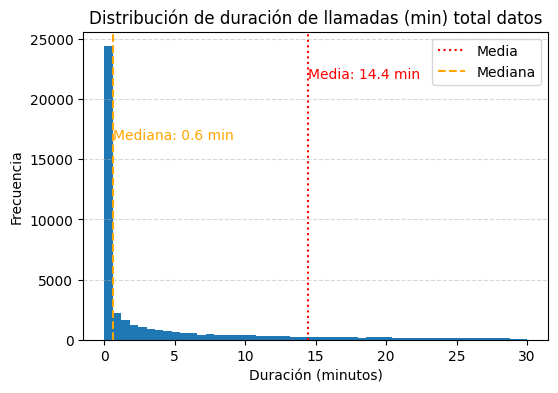

In [283]:
# Histograma de la variable de duración de llamadas -- full
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

# Histograma
plt.hist(
    telecom_full['call_duration_min'],
    bins=50,
    range=(0, 30),
)

# Calcular valores
mean_val = telecom_full['call_duration_min'].mean()
median_val = telecom_full['call_duration_min'].median()

# Líneas
plt.axvline(mean_val, color='red', linestyle=':', label='Media')
plt.axvline(median_val, color='orange', linestyle='--', label='Mediana')

# Etiquetas
plt.text(mean_val, plt.ylim()[1]*0.85, f'Media: {mean_val:.1f} min', color='red')
plt.text(median_val, plt.ylim()[1]*0.65, f'Mediana: {median_val:.1f} min', color='orange')

# Títulos
plt.title('Distribución de duración de llamadas (min) total datos')
plt.xlabel('Duración (minutos)')
plt.ylabel('Frecuencia')

plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

In [284]:
# Ahora separamos los típicos de outliers aplicando IQR en variable call_duration_min

# Calcular Q1, Q3 e IQR para call_duration_min
Q1 = telecom_full['call_duration_min'].quantile(0.25)
Q3 = telecom_full['call_duration_min'].quantile(0.75)
IQR = Q3 - Q1

# Límites según la regla IQR
lim_inf = Q1 - 1.5 * IQR
lim_sup = Q3 + 1.5 * IQR

print(f"Límite inferior: {lim_inf:.2f}")
print(f"Límite superior: {lim_sup:.2f}")

# Separar típicos y outliers
tipicos_duration = telecom_full[
    (telecom_full['call_duration_min'] >= lim_inf) &
    (telecom_full['call_duration_min'] <= lim_sup)
].copy()

outliers_duration = telecom_full[
    (telecom_full['call_duration_min'] < lim_inf) |
    (telecom_full['call_duration_min'] > lim_sup)
].copy()

print("Cantidad de típicos:", len(tipicos_duration))
print("Cantidad de outliers:", len(outliers_duration))

Límite inferior: -14.25
Límite superior: 23.75
Cantidad de típicos: 42136
Cantidad de outliers: 6866


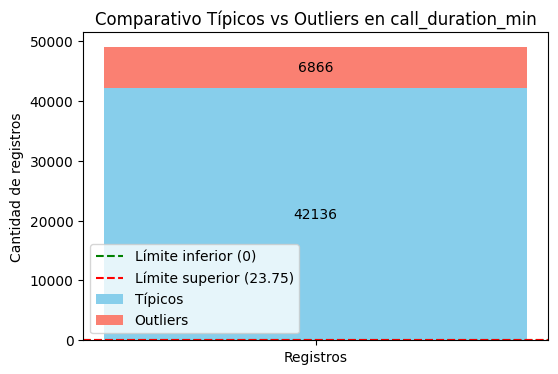

In [285]:

# Gráfico compartivo tipico vs outliers en variable call-duration_min

tipicos = 42136
outliers = 6866
lim_inf = 0       # ajustado desde -14.25
lim_sup = 23.75

# Crear gráfico de barras apiladas
fig, ax = plt.subplots(figsize=(6,4))
ax.bar("Registros", tipicos, color="skyblue", label="Típicos")
ax.bar("Registros", outliers, bottom=tipicos, color="salmon", label="Outliers")

# Añadir etiquetas de valores
ax.text(0, tipicos/2, str(tipicos), ha="center", va="center", fontsize=10, color="black")
ax.text(0, tipicos + outliers/2, str(outliers), ha="center", va="center", fontsize=10, color="black")

# Líneas horizontales para los límites IQR
ax.axhline(y=lim_inf, color="green", linestyle="--", label=f"Límite inferior ({lim_inf})")
ax.axhline(y=lim_sup, color="red", linestyle="--", label=f"Límite superior ({lim_sup})")

# Títulos y leyenda
ax.set_title("Comparativo Típicos vs Outliers en call_duration_min")
ax.set_ylabel("Cantidad de registros")
ax.legend()

plt.show()

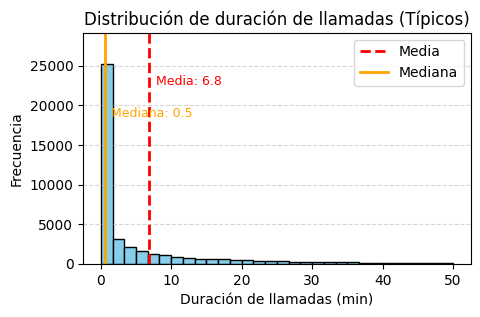

In [286]:
# Histograma de duración de llamadas (Típicos)

plt.figure(figsize=(5,3))

# Histograma
plt.hist(
    tipicos_calls['call_duration_min'],  # 👈 aquí está el cambio clave
    bins=30,
    range=(0, 50),
    color="skyblue",
    edgecolor="black"
)

# Calcular valores
mean_val = tipicos_calls['call_duration_min'].mean()
median_val = tipicos_calls['call_duration_min'].median()

# Líneas de referencia
plt.axvline(mean_val, color='red', linestyle='--', linewidth=2, label='Media')
plt.axvline(median_val, color='orange', linestyle='-', linewidth=2, label='Mediana')

# Etiquetas bien posicionadas (sin que se monten)
for val, label, color, offset in [
    (mean_val, 'Media', 'red', 0.85),
    (median_val, 'Mediana', 'orange', 0.7)
]:
    plt.annotate(
        f'{label}: {val:.1f}',
        xy=(val, plt.ylim()[1]*offset),
        xytext=(5, 0),
        textcoords='offset points',
        color=color,
        fontsize=9
    )

# Espacio arriba
plt.ylim(0, plt.ylim()[1] * 1.1)

# Títulos
plt.title('Distribución de duración de llamadas (Típicos)')
plt.xlabel('Duración de llamadas (min)')
plt.ylabel('Frecuencia')

plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

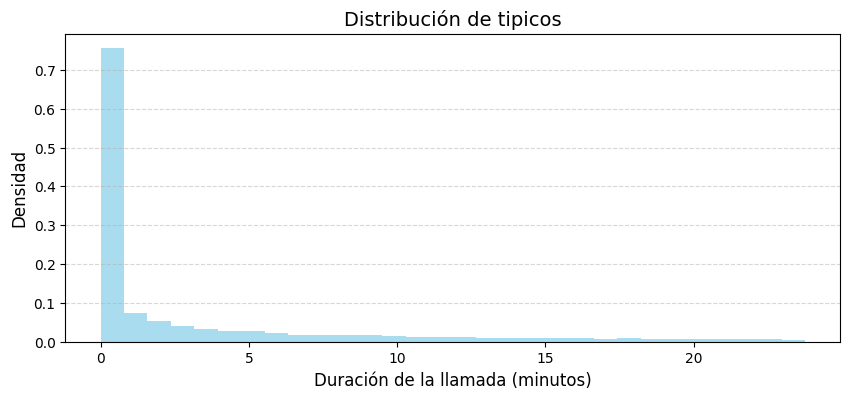

In [287]:
# histograma con llamadas de menos de 60 min de duración

plt.figure(figsize=(10,4))

# Histograma de densidad
telecom_full[telecom_full['call_duration_min'] <= 23.75]['call_duration_min'].plot(
    kind='hist',
    bins=30,
    density=True,  # esto lo hace densidad
    alpha=0.7,
    color='skyblue'
)

plt.title('Distribución de tipicos', fontsize=14)
plt.xlabel('Duración de la llamada (minutos)', fontsize=12)
plt.ylabel('Densidad', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

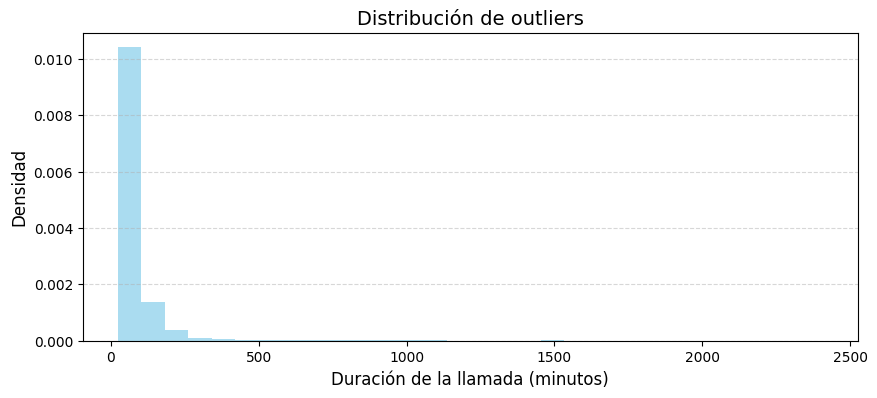

In [288]:
plt.figure(figsize=(10,4))

# Histograma de densidad para duración de llmadas de más de 60 min
telecom_full[telecom_full['call_duration_min'] > 23.75]['call_duration_min'].plot(
    kind='hist',
    bins=30,
    density=True,  # esto lo hace densidad
    alpha=0.7,
    color='skyblue'
)

plt.title('Distribución de outliers', fontsize=14)
plt.xlabel('Duración de la llamada (minutos)', fontsize=12)
plt.ylabel('Densidad', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

Análisis de la variable calls_count

In [289]:
# Estadísticas descriptivas del total de datos call_count -- full
calls_count_stats = telecom_full['calls_count'].describe()
calls_count_stats

count    49002.000000
mean        16.462777
std         63.604098
min          1.000000
25%          1.000000
50%          4.000000
75%         12.000000
max       4817.000000
Name: calls_count, dtype: float64

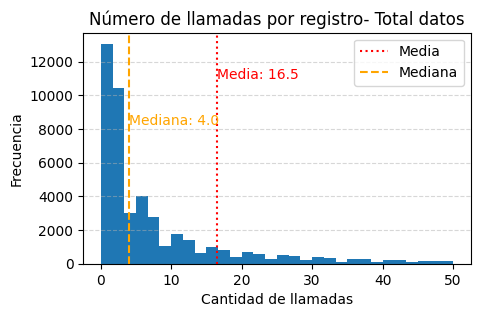

In [290]:
# Histograma de número de llamadas por registro- full

plt.figure(figsize=(5,3))

# Histograma
plt.hist(
    telecom_full['calls_count'],
    bins=30,
    range=(0, 50)
)

# Calcular valores
mean_val = telecom_full['calls_count'].mean()
median_val = telecom_full['calls_count'].median()

# Líneas
plt.axvline(mean_val, color='red', linestyle=':', label='Media')
plt.axvline(median_val, color='orange', linestyle='--', label='Mediana')

# Etiquetas (texto en el gráfico)
plt.text(mean_val, plt.ylim()[1]*0.8, f'Media: {mean_val:.1f}', color='red')
plt.text(median_val, plt.ylim()[1]*0.6, f'Mediana: {median_val:.1f}', color='orange')

# Títulos
plt.title('Número de llamadas por registro- Total datos')
plt.xlabel('Cantidad de llamadas')
plt.ylabel('Frecuencia')

plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

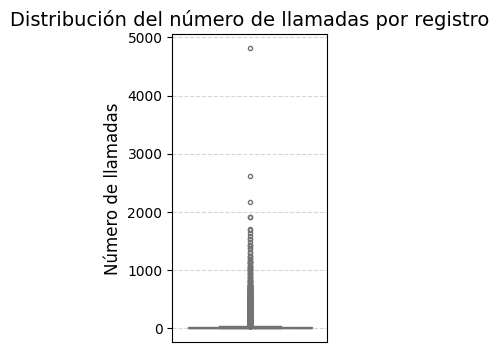

In [291]:
# boxplot del número de llamadas por registro -- full

plt.figure(figsize=(2,4))
sns.boxplot(
    y='calls_count', 
    data=telecom_full, 
    color='lightgreen',
    fliersize=3
)
plt.title('Distribución del número de llamadas por registro', fontsize=14)
plt.ylabel('Número de llamadas', fontsize=12)
plt.xticks([])
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

In [292]:
# Separación de típicos de outliers de variable call_count (IQR)

# Calcular Q1, Q3 e IQR para calls_count
Q1 = telecom_full['calls_count'].quantile(0.25)
Q3 = telecom_full['calls_count'].quantile(0.75)
IQR = Q3 - Q1

lim_inf = Q1 - 1.5 * IQR
lim_sup = Q3 + 1.5 * IQR

print(f"Límite inferior: {lim_inf:.2f}")
print(f"Límite superior: {lim_sup:.2f}")

# Separar típicos y outliers
tipicos_calls = telecom_full[
    (telecom_full['calls_count'] >= lim_inf) &
    (telecom_full['calls_count'] <= lim_sup)
].copy()

outliers_calls = telecom_full[
    (telecom_full['calls_count'] < lim_inf) |
    (telecom_full['calls_count'] > lim_sup)
].copy()

print("Cantidad de típicos:", len(tipicos_calls))
print("Cantidad de outliers:", len(outliers_calls))

Límite inferior: -15.50
Límite superior: 28.50
Cantidad de típicos: 42955
Cantidad de outliers: 6047


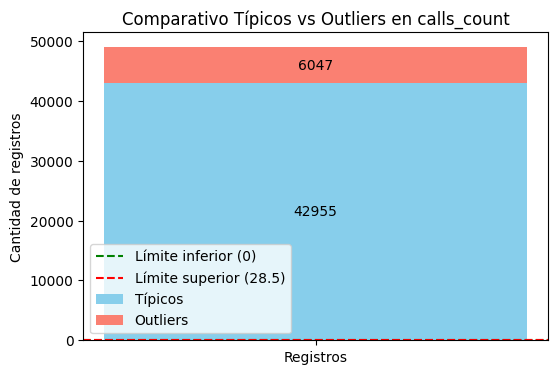

In [293]:
# Grafico típicos vs outliers en la variable call_count

# Datos
tipicos = 42955
outliers = 6047
lim_inf = 0       # ajustado desde -15.50
lim_sup = 28.50

# Crear gráfico de barras apiladas
fig, ax = plt.subplots(figsize=(6,4))
ax.bar("Registros", tipicos, color="skyblue", label="Típicos")
ax.bar("Registros", outliers, bottom=tipicos, color="salmon", label="Outliers")

# Añadir etiquetas de valores
ax.text(0, tipicos/2, str(tipicos), ha="center", va="center", fontsize=10, color="black")
ax.text(0, tipicos + outliers/2, str(outliers), ha="center", va="center", fontsize=10, color="black")

# Líneas horizontales para los límites IQR
ax.axhline(y=lim_inf, color="green", linestyle="--", label=f"Límite inferior ({lim_inf})")
ax.axhline(y=lim_sup, color="red", linestyle="--", label=f"Límite superior ({lim_sup})")

# Títulos y leyenda
ax.set_title("Comparativo Típicos vs Outliers en calls_count")
ax.set_ylabel("Cantidad de registros")
ax.legend()

plt.show()

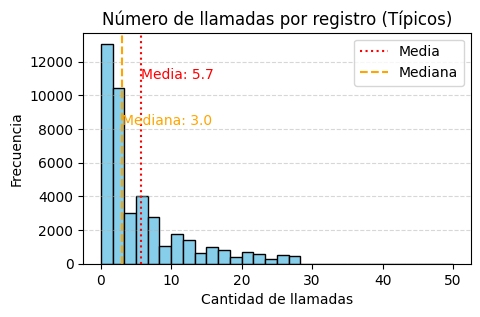

In [294]:
# gráfico histograma de los típicos call_count


plt.figure(figsize=(5,3))

# Histograma de los típicos
plt.hist(
    tipicos_calls['calls_count'],
    bins=30,
    range=(0, 50),
    color="skyblue",
    edgecolor="black"
)

# Calcular valores
mean_val = tipicos_calls['calls_count'].mean()
median_val = tipicos_calls['calls_count'].median()

# Líneas de referencia
plt.axvline(mean_val, color='red', linestyle=':', label='Media')
plt.axvline(median_val, color='orange', linestyle='--', label='Mediana')

# Etiquetas en el gráfico
plt.text(mean_val, plt.ylim()[1]*0.8, f'Media: {mean_val:.1f}', color='red')
plt.text(median_val, plt.ylim()[1]*0.6, f'Mediana: {median_val:.1f}', color='orange')

# Títulos y ejes
plt.title('Número de llamadas por registro (Típicos)')
plt.xlabel('Cantidad de llamadas')
plt.ylabel('Frecuencia')

plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

Análisis de variable total_call_duration (duración total de llamdas por registro)

In [295]:
# Estadísticas descriptivas de duración total de llamadas por registro
total_call_stats = telecom_full['total_call_duration_min'].describe()
total_call_stats

count    49002.000000
mean        19.275970
std         74.191228
min          0.000000
25%          0.766667
50%          3.466667
75%         15.016667
max       2769.250000
Name: total_call_duration_min, dtype: float64

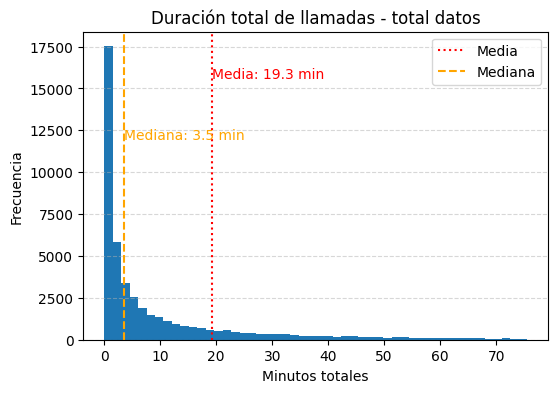

In [296]:
# Histograma de la duración total de llamadas -- full

plt.figure(figsize=(6,4))

#  límite inteligente
limit = telecom_full['total_call_duration_min'].quantile(0.95)

# Histograma
plt.hist(
    telecom_full['total_call_duration_min'],
    bins=50,
    range=(0, limit)
)

# Media y mediana
mean_val = telecom_full['total_call_duration_min'].mean()
median_val = telecom_full['total_call_duration_min'].median()

plt.axvline(mean_val, color='red', linestyle=':', label='Media')
plt.axvline(median_val, color='orange', linestyle='--', label='Mediana')

# Etiquetas
plt.text(mean_val, plt.ylim()[1]*0.85, f'Media: {mean_val:.1f} min', color='red')
plt.text(median_val, plt.ylim()[1]*0.65, f'Mediana: {median_val:.1f} min', color='orange')

# Títulos
plt.title('Duración total de llamadas - total datos')
plt.xlabel('Minutos totales')
plt.ylabel('Frecuencia')

plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

In [297]:
# Separación de típicos vs outliers 

# Calcular Q1, Q3 e IQR para total_call_duration_min
Q1 = telecom_full['total_call_duration_min'].quantile(0.25)
Q3 = telecom_full['total_call_duration_min'].quantile(0.75)
IQR = Q3 - Q1

lim_inf = Q1 - 1.5 * IQR
lim_sup = Q3 + 1.5 * IQR

print(f"Límite inferior: {lim_inf:.2f}")
print(f"Límite superior: {lim_sup:.2f}")

# Separar típicos y outliers
tipicos_total = telecom_full[
    (telecom_full['total_call_duration_min'] >= lim_inf) &
    (telecom_full['total_call_duration_min'] <= lim_sup)
].copy()

outliers_total = telecom_full[
    (telecom_full['total_call_duration_min'] < lim_inf) |
    (telecom_full['total_call_duration_min'] > lim_sup)
].copy()

print("Cantidad de típicos:", len(tipicos_total))
print("Cantidad de outliers:", len(outliers_total))

Límite inferior: -20.61
Límite superior: 36.39
Cantidad de típicos: 43070
Cantidad de outliers: 5932


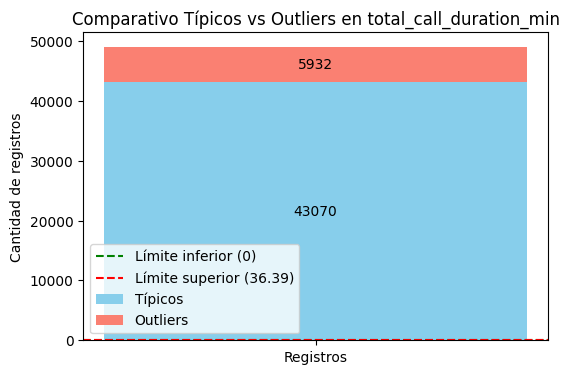

In [298]:
# Gráfico de típicos vs outliers en la variable total_call_duration_min

# Datos
tipicos = 43070
outliers = 5932
lim_inf = 0       # ajustado desde -20.61
lim_sup = 36.39

# Crear gráfico de barras apiladas
fig, ax = plt.subplots(figsize=(6,4))
ax.bar("Registros", tipicos, color="skyblue", label="Típicos")
ax.bar("Registros", outliers, bottom=tipicos, color="salmon", label="Outliers")

# Añadir etiquetas de valores
ax.text(0, tipicos/2, str(tipicos), ha="center", va="center", fontsize=10, color="black")
ax.text(0, tipicos + outliers/2, str(outliers), ha="center", va="center", fontsize=10, color="black")

# Líneas horizontales para los límites IQR
ax.axhline(y=lim_inf, color="green", linestyle="--", label=f"Límite inferior ({lim_inf})")
ax.axhline(y=lim_sup, color="red", linestyle="--", label=f"Límite superior ({lim_sup})")

# Títulos y leyenda
ax.set_title("Comparativo Típicos vs Outliers en total_call_duration_min")
ax.set_ylabel("Cantidad de registros")
ax.legend()

plt.show()

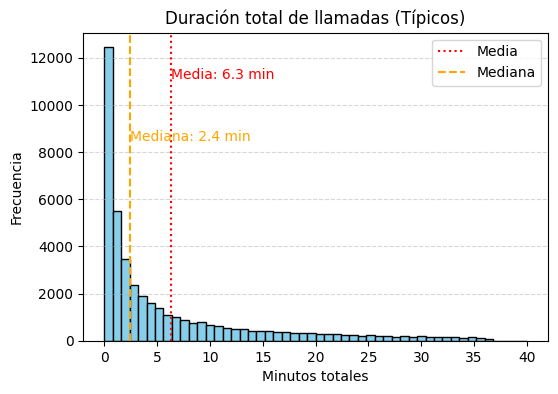

In [299]:
# Histograma de los típicos de la variable duración total 

import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

# Histograma de los típicos
plt.hist(
    tipicos_total['total_call_duration_min'],
    bins=50,
    range=(0, 40),   # rango ajustado al límite superior típico (36.39 aprox.)
    color="skyblue",
    edgecolor="black"
)

# Media y mediana de los típicos
mean_val = tipicos_total['total_call_duration_min'].mean()
median_val = tipicos_total['total_call_duration_min'].median()

# Líneas de referencia
plt.axvline(mean_val, color='red', linestyle=':', label='Media')
plt.axvline(median_val, color='orange', linestyle='--', label='Mediana')

# Etiquetas en el gráfico
plt.text(mean_val, plt.ylim()[1]*0.85, f'Media: {mean_val:.1f} min', color='red')
plt.text(median_val, plt.ylim()[1]*0.65, f'Mediana: {median_val:.1f} min', color='orange')

# Títulos y ejes
plt.title('Duración total de llamadas (Típicos)')
plt.xlabel('Minutos totales')
plt.ylabel('Frecuencia')

plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

In [300]:
# Unimos los típicos en un solo dataset

# Reunir las tres variables de típicos en una sola
tipicos = pd.concat([tipicos_duration, tipicos_calls, tipicos_total])

print("Cantidad total de registros típicos reunidos:", len(tipicos))
print(tipicos.head())

Cantidad total de registros típicos reunidos: 128161
   user_id                      date direction  internal  operator_id  \
0   166377 2019-08-04 00:00:00+03:00        in     False         <NA>   
1   166377 2019-08-05 00:00:00+03:00       out      True       880022   
2   166377 2019-08-05 00:00:00+03:00       out      True       880020   
3   166377 2019-08-05 00:00:00+03:00       out      True       880020   
4   166377 2019-08-05 00:00:00+03:00       out     False       880022   

   is_missed_call  calls_count  call_duration  total_call_duration  \
0            True            2              0                    4   
1            True            3              0                    5   
2            True            1              0                    1   
3           False            1             10                   18   
4            True            3              0                   25   

  tariff_plan date_start  call_duration_min  total_call_duration_min  
0           B 20

In [301]:
#unimos outliers en un solo dataset

# Reunir las tres variables de outliers en una sola
outliers = pd.concat([outliers_duration, outliers_calls, outliers_total])

print("Cantidad total de registros outliers reunidos:", len(outliers))
print(outliers.head())

Cantidad total de registros outliers reunidos: 18845
    user_id                      date direction  internal  operator_id  \
20   166377 2019-08-09 00:00:00+03:00       out     False       880028   
23   166377 2019-08-12 00:00:00+03:00       out     False       880028   
39   166377 2019-08-14 00:00:00+03:00       out     False       880028   
41   166377 2019-08-14 00:00:00+03:00       out     False       880026   
44   166377 2019-08-15 00:00:00+03:00       out     False       880028   

    is_missed_call  calls_count  call_duration  total_call_duration  \
20           False           17           1603                 1725   
23           False           20           2074                 2191   
39           False           18           2686                 2782   
41           False           10           1567                 1654   
44           False           19           2653                 2779   

   tariff_plan date_start  call_duration_min  total_call_duration_min  
20 

Definición de umbrales para las anteriores 3 variables para evitar alteraciones métricas

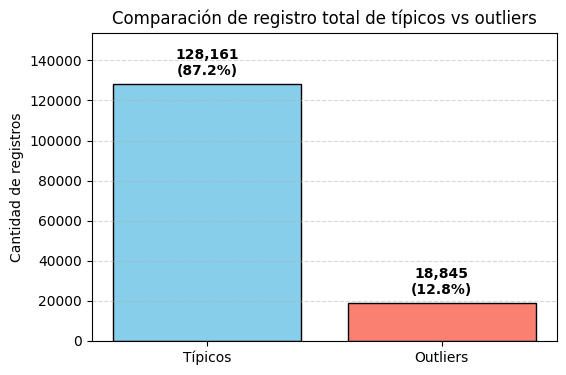

In [302]:
# Gráfico de Separación de típicos y outliers
# Cantidades
tipicos_count = len(tipicos)
outliers_count = len(outliers)

total = tipicos_count + outliers_count

# Datos para la gráfica
categorias = ['Típicos', 'Outliers']
valores = [tipicos_count, outliers_count]
colores = ['skyblue', 'salmon']

plt.figure(figsize=(6,4))

# Gráfico de barras
bars = plt.bar(categorias, valores, color=colores, edgecolor='black')

# Etiquetas encima de cada barra (con porcentaje)
for bar, valor in zip(bars, valores):
    porcentaje = valor / total * 100
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 3000,
        f'{valor:,}\n({porcentaje:.1f}%)',  # 👈 aquí agregas el %
        ha='center', va='bottom',
        fontsize=10, fontweight='bold'
    )

# Títulos y ejes
plt.title('Comparación de registro total de típicos vs outliers')
plt.ylabel('Cantidad de registros')

plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.ylim(0, max(valores) * 1.2)
plt.show()

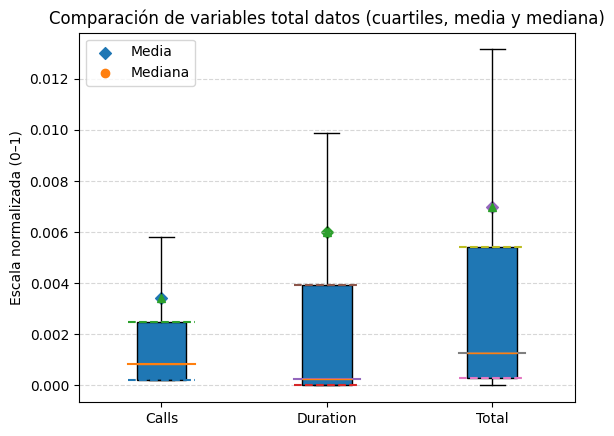

In [303]:
# Gráfico inicialmente comparativo de comportamiento de las 3 variables -full(incluyendo outliers)

#plt.figure(figsize=(6,5))

#  Normalizar variables
calls_norm = telecom_full['calls_count'] / telecom_full['calls_count'].max()
dur_norm = telecom_full['call_duration_min'] / telecom_full['call_duration_min'].max()
total_norm = telecom_full['total_call_duration_min'] / telecom_full['total_call_duration_min'].max()

data = [calls_norm, dur_norm, total_norm]
labels = ['Calls', 'Duration', 'Total']

# Boxplot
plt.boxplot(
    data,
    patch_artist=True,
    showmeans=True,
    showfliers=False
)

# Cuartiles + media + mediana
for i, var in enumerate(data):
    Q1 = var.quantile(0.25)
    Q2 = var.quantile(0.50)
    Q3 = var.quantile(0.75)
    mean = var.mean()
    
    # Cuartiles
    plt.plot([i+0.8, i+1.2], [Q1, Q1], linestyle='--')
    plt.plot([i+0.8, i+1.2], [Q2, Q2], linestyle='-')
    plt.plot([i+0.8, i+1.2], [Q3, Q3], linestyle='--')
    
    # 🔴 Media (solo una vez en la leyenda)
    plt.scatter(i+1, mean, marker='D', label='Media' if i == 0 else "")
    
    # 🟧 Mediana (AGREGAR ESTO)
    plt.scatter(i+1, Q2, marker='o', label='Mediana' if i == 0 else "")

# Etiquetas
plt.xticks([1,2,3], labels)
plt.title('Comparación de variables total datos (cuartiles, media y mediana)')
plt.ylabel('Escala normalizada (0–1)')

plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

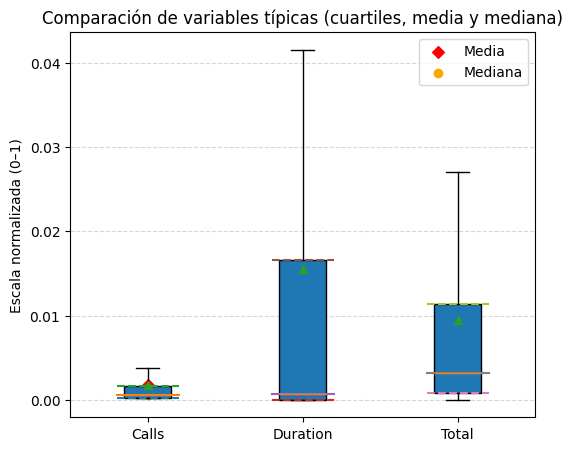

In [304]:
# grafico a hora las 3 variables con los típicos unicamente

plt.figure(figsize=(6,5))

# Normalizar variables en el df tipicos
calls_norm = tipicos['calls_count'] / tipicos['calls_count'].max()
dur_norm = tipicos['call_duration_min'] / tipicos['call_duration_min'].max()
total_norm = tipicos['total_call_duration_min'] / tipicos['total_call_duration_min'].max()

data = [calls_norm, dur_norm, total_norm]
labels = ['Calls', 'Duration', 'Total']

# Boxplot
plt.boxplot(
    data,
    patch_artist=True,
    showmeans=True,
    showfliers=False
)

# Cuartiles + media + mediana
for i, var in enumerate(data):
    Q1 = var.quantile(0.25)
    Q2 = var.quantile(0.50)
    Q3 = var.quantile(0.75)
    mean = var.mean()
    
    # Cuartiles
    plt.plot([i+0.8, i+1.2], [Q1, Q1], linestyle='--')
    plt.plot([i+0.8, i+1.2], [Q2, Q2], linestyle='-')
    plt.plot([i+0.8, i+1.2], [Q3, Q3], linestyle='--')
    
    # 🔴 Media (solo una vez en la leyenda)
    plt.scatter(i+1, mean, marker='D', color='red', label='Media' if i == 0 else "")
    
    # 🟧 Mediana (solo una vez en la leyenda)
    plt.scatter(i+1, Q2, marker='o', color='orange', label='Mediana' if i == 0 else "")

# Etiquetas
plt.xticks([1,2,3], labels)
plt.title('Comparación de variables típicas (cuartiles, media y mediana)')
plt.ylabel('Escala normalizada (0–1)')

plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

Típicos, cuantiles, umbrales, score, semáforo:

En adelate trabajaremos sólo con el conjunto de datos típicos. Adicionalmente y con el fin de establecer unos umbrales (basados en IQR) que sirvan como base para iniciar el proceso de identificación de operariios ineficientes (apoyados en un score y semáforo), se verifican inicialmente los respectivos cuantiles del dataset(típicos)

In [305]:
# Verifico ahora los cuantiles -- típicos

q25_calls = tipicos['calls_count'].quantile(0.25)
q50_calls = tipicos['calls_count'].quantile(0.50)

q50_duration = tipicos['call_duration_min'].quantile(0.50)
q75_duration = tipicos['call_duration_min'].quantile(0.75)

q50_total = tipicos['total_call_duration_min'].quantile(0.50)
q75_total = tipicos['total_call_duration_min'].quantile(0.75)

q50_missed = tipicos['is_missed_call'].mean()

print(
    f"Quantiles (datos típicos):\n"
    
    f"q25_calls: {q25_calls:.2f}\n"
    f"q50_calls: {q50_calls:.2f}\n"
    
    f"q50_duration: {q50_duration:.2f}\n"
    f"q75_duration: {q75_duration:.2f}\n"
    
    f"q50_total: {q50_total:.2f}\n"
    f"q75_total: {q75_total:.2f}\n"

    f"q50_missed: {q50_missed:.2f}\n"
)

Quantiles (datos típicos):
q25_calls: 1.00
q50_calls: 3.00
q50_duration: 0.22
q75_duration: 4.97
q50_total: 2.40
q75_total: 8.55
q50_missed: 0.48



In [306]:
# Definición de umbrales para los típicos a partir de quantiles

umbrales_tipicos = {
    'calls_muy_bajo': int(q25_calls),
    'calls_bajo': int(q50_calls),
    'duration_alta': round(float(q50_duration), 2),
    'duration_muy_alta': round(float(q75_duration), 2),
    'total_alta': round(float(q50_total), 2),
    'total_muy_alta': round(float(q75_total), 2),
    'missed_promedio': round(float(q50_missed), 1)  # porcentaje promedio
}

tabla_umbrales = pd.DataFrame(
    list(umbrales_tipicos.items()),
    columns=['Umbral', 'Valor']
)

print(tabla_umbrales.to_string(index=False))

           Umbral  Valor
   calls_muy_bajo   1.00
       calls_bajo   3.00
    duration_alta   0.22
duration_muy_alta   4.97
       total_alta   2.40
   total_muy_alta   8.55
  missed_promedio   0.50


In [307]:
## prueba

telecom_new['is_missed_call']

0         True
1         True
2         True
3        False
4         True
         ...  
53896    False
53897     True
53898    False
53899    False
53901     True
Name: is_missed_call, Length: 49002, dtype: bool

In [308]:
# construcción de score de calificación eficiencia y productividad

def score_fila(row):
    score = 0
    
    # Calls (bajo = malo)
    if row['calls_count'] <= umbrales_tipicos['calls_muy_bajo']:
        score += 2
    elif row['calls_count'] <= umbrales_tipicos['calls_bajo']:
        score += 1

    # Duración (alto = sospechoso)
    if row['call_duration_min'] > umbrales_tipicos['duration_muy_alta']:
        score += 2
    elif row['call_duration_min'] > umbrales_tipicos['duration_alta']:
        score += 1

    # Total (alto = sospechoso)
    if row['total_call_duration_min'] > umbrales_tipicos['total_muy_alta']:
        score += 2
    elif row['total_call_duration_min'] > umbrales_tipicos['total_alta']:
        score += 1

    # Missed calls (alto = malo)
    if row['is_missed_call'] >= 0.60:   # 60% o más perdidas
        score += 2
    elif row['is_missed_call'] >= 0.10: # entre 10% y 59%
        score += 1
    else:
        score += 0

    return score

tipicos['ineff_score'] = tipicos.apply(score_fila, axis=1)

In [309]:
# Distribución del score de ineficiencia
plt.figure(figsize=(6,4))

# Conteo por s

<Figure size 600x400 with 0 Axes>

<Figure size 600x400 with 0 Axes>

In [310]:
# construir resumen por operador -- típicos

operador_summary_tipicos = tipicos.groupby('operator_id').agg(
    ineff_score_mean=('ineff_score', 'mean'),
    ineff_score_median=('ineff_score', 'median'),
    missed_call_rate=('is_missed_call', 'mean'),
    total_calls=('operator_id', 'count'),
    total_duration=('total_call_duration_min', 'sum')
).reset_index()

In [311]:
# validación

print(operador_summary_tipicos['ineff_score_mean'].describe())

count    1092.000000
mean        3.260635
std         0.505450
min         1.000000
25%         3.000000
50%         3.278338
75%         3.520435
max         6.000000
Name: ineff_score_mean, dtype: float64


4.2 Análisis por tipo de llamada 

In [312]:
#a.  Tasa de llamadas perdidas por dirección de llamada(in / out)

# Tasa de llamadas perdidas por dirección en porcentaje
lost_rate_dir_pct = (tipicos.groupby('direction')['is_missed_call'].mean() * 100).round(2)

print("Tasa de llamadas perdidas por dirección (%):\n", lost_rate_dir_pct)

Tasa de llamadas perdidas por dirección (%):
 direction
in     41.46
out    52.56
Name: is_missed_call, dtype: float64


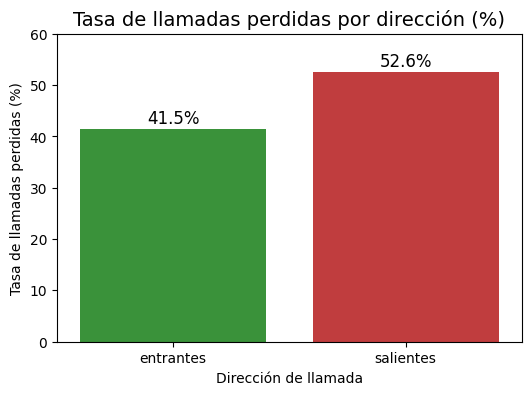

In [313]:
# gráfico tasa de llamadas perdidas por dirección

# Datos
missed_rate = pd.Series([41.46, 52.56], index=['entrantes', 'salientes'])
df_missed = missed_rate.reset_index()
df_missed.columns = ['direction', 'missed']

# Crear figura
plt.figure(figsize=(6,4))
sns.barplot(data=df_missed, x='direction', y='missed', hue='direction', dodge=False,
            palette=['#2ca02c', '#d62728'], legend=False)

# Etiquetas
plt.title("Tasa de llamadas perdidas por dirección (%)", fontsize=14)
plt.xlabel("Dirección de llamada")
plt.ylabel("Tasa de llamadas perdidas (%)")
plt.ylim(0, 60)

# Mostrar valor encima de cada barra
for i, val in enumerate(df_missed['missed']):
    plt.text(i, val + 1, f"{val:.1f}%", ha='center', fontsize=12)

plt.show()

In [314]:
#b. Duración promedio por dirección de llamada
avg_time_dir = tipicos.groupby('direction')['call_duration_min'].median().round(2)
print("\nDuración promedio por dirección:\n", avg_time_dir)



Duración promedio por dirección:
 direction
in     0.63
out    0.00
Name: call_duration_min, dtype: float64


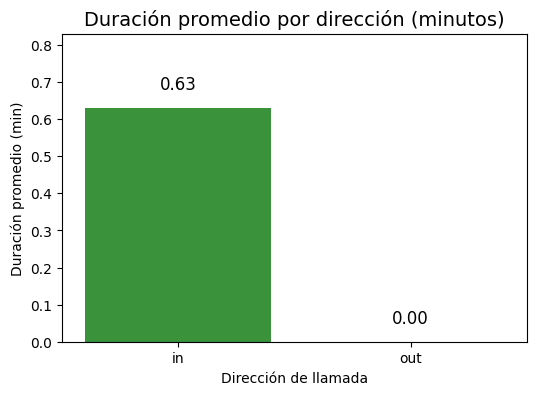

In [ ]:
# gráfico duración promedio por dirección

# Datos
duration_avg = pd.Series([0.63, 0.00], index=['in', 'out'])
df_duration = duration_avg.reset_index()
df_duration.columns = ['direction', 'duration']

# Crear figura
plt.figure(figsize=(6,4))
sns.barplot(data=df_duration, x='direction', y='duration', hue='direction', dodge=False,
            palette=['#2ca02c', '#d62728'], legend=False)

# Etiquetas
plt.title("Duración promedio por dirección (minutos)", fontsize=14)
plt.xlabel("Dirección de llamada")
plt.ylabel("Duración promedio (min)")
plt.ylim(0, max(df_duration['duration']) + 0.2)

# Mostrar valor encima de cada barra
for i, val in enumerate(df_duration['duration']):
    plt.text(i, val + 0.05, f"{val:.2f}", ha='center', fontsize=12)

plt.show()

In [316]:
#c. Tasa de llamadas perdidas por llamadas internas/externas
lost_rate_internal = tipicos.groupby('internal')['is_missed_call'].mean().round(2)
print("Tasa de llamadas perdidas por llamadas internas/externas (%):\n", lost_rate_internal)


Tasa de llamadas perdidas por llamadas internas/externas (%):
 internal
False    0.48
True     0.48
Name: is_missed_call, dtype: float64


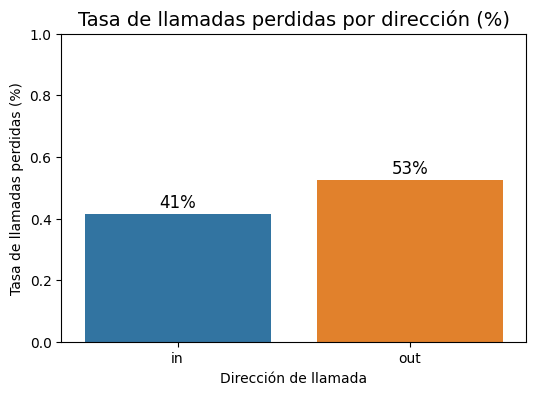

In [320]:
# tasa de llamadas perdidas internas y externas

missed_internal = tipicos.groupby('direction')['is_missed_call'].mean()

df_internal = missed_internal.reset_index()
df_internal.columns = ['direction', 'missed']

# Crear figura
plt.figure(figsize=(6,4))
sns.barplot(data=df_internal, x='direction', y='missed', hue='direction', dodge=False,
            palette=['#1f77b4', '#ff7f0e'], legend=False)

# Etiquetas
plt.title("Tasa de llamadas perdidas por dirección (%)", fontsize=14)
plt.xlabel("Dirección de llamada")
plt.ylabel("Tasa de llamadas perdidas (%)")
plt.ylim(0, 1)

# Mostrar valor encima de cada barra en porcentaje
for i, val in enumerate(df_internal['missed']):
    plt.text(i, val + 0.02, f"{val*100:.0f}%", ha='center', fontsize=12)

plt.show()

In [ ]:
#d.  Duración mediana por llamadas internas/externas
avg_time_internal = (
    tipicos.groupby('internal')['call_duration_min']
    .median()
    .round(2)
    .reset_index()
    .rename(columns={'internal': 'tipo_llamada', 'call_duration_min': 'duracion_mediana'})
)

# Mapear True/False a etiquetas claras
avg_time_internal['tipo_llamada'] = avg_time_internal['tipo_llamada'].map({True: 'Internas', False: 'Externas'})

print("\nDuración promedio (mediana) por llamadas internas/externas:\n", avg_time_internal)


Duración promedio (mediana) por llamadas internas/externas:
   tipo_llamada  duracion_mediana
0     Externas              0.27
1     Internas              0.10


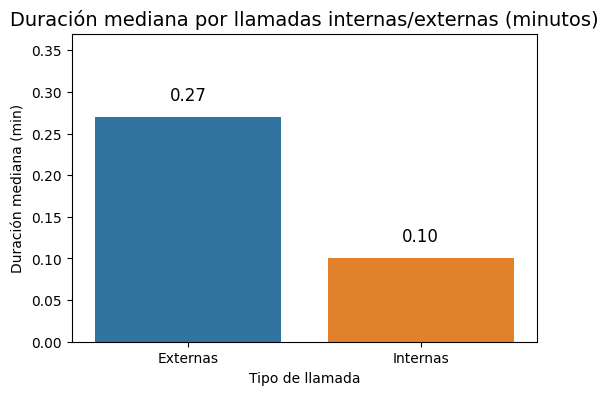

In [ ]:
# duración mediana por llamdas internas y externas
# Datos
df_duration_internal = pd.DataFrame({
    'tipo_llamada': ['Externas', 'Internas'],
    'duracion_mediana': [0.27, 0.10]
})

# Crear figura
plt.figure(figsize=(6,4))
sns.barplot(data=df_duration_internal, x='tipo_llamada', y='duracion_mediana', hue='tipo_llamada',
            dodge=False, palette=['#1f77b4', '#ff7f0e'], legend=False)

# Etiquetas
plt.title("Duración mediana por llamadas internas/externas (minutos)", fontsize=14)
plt.xlabel("Tipo de llamada")
plt.ylabel("Duración mediana (min)")
plt.ylim(0, max(df_duration_internal['duracion_mediana']) + 0.1)

# Mostrar valor encima de cada barra
for i, val in enumerate(df_duration_internal['duracion_mediana']):
    plt.text(i, val + 0.02, f"{val:.2f}", ha='center', fontsize=12)

plt.show()

4.3 Primer insight de ineficiencia

las llamadas salientes representan un punto crítico de ineficiencia dentro de la operación, constituyéndose como una prioridad para análisis posteriores orientados a identificar causas raíz y definir acciones de mejora.


4.4 Análisis por operador

In [ ]:
# Confirmo la cantidad de operadores analizados

print("Operadores únicos:", tipicos['operator_id'].nunique())

Operadores únicos: 1092


In [ ]:
# Revisión inicial de infeff_score 

print(tipicos['ineff_score'].describe())
print(tipicos['ineff_score'].value_counts())

count    128161.000000
mean          3.305397
std           0.850638
min           0.000000
25%           3.000000
50%           3.000000
75%           4.000000
max           8.000000
Name: ineff_score, dtype: float64
ineff_score
4    53362
3    45957
2    22863
5     4073
1     1044
6      826
7       27
0        6
8        3
Name: count, dtype: int64


a. Análisis de productividad y eficiencia general por operador

In [ ]:
# Semáforo de niveles de productividad y cumplimiento por operador

#  1️⃣ Semáforo dinámico para ineff_score_mean
# =========================================

# Calcular percentiles para el semáforo
q25 = operador_summary_tipicos['ineff_score_mean'].quantile(0.25)
q50 = operador_summary_tipicos['ineff_score_mean'].quantile(0.50)
q75 = operador_summary_tipicos['ineff_score_mean'].quantile(0.75)

# Función de semáforo dinámico
def sem_ineff_dynamic(x):
    if x > q75:
        return '🔴 Crítico'
    elif x > q50:
        return '🟠 Riesgo medio'
    elif x > q25:
        return '🟡 Alerta leve'
    else:
        return '🟢 Excelente'

# Aplicar semáforo a cada operador
operador_summary_tipicos['ineff_score_semaforo'] = operador_summary_tipicos['ineff_score_mean'].apply(sem_ineff_dynamic)

# =========================================
# 2️⃣ Ranking de operadores por ineff_score
# =========================================
ranking_operadores = operador_summary_tipicos.sort_values(
    'ineff_score_mean', ascending=False
)[['operator_id', 'ineff_score_mean', 'ineff_score_semaforo', 
   'missed_call_rate', 'total_calls', 'total_duration']]

# Mostrar top 10 operadores más ineficientes
print("\n📋 Top 10 operadores más ineficientes:\n")
display(ranking_operadores.head(10))

# =========================================
# 3️⃣ Conteo y porcentaje de operadores por semáforo
# =========================================
conteo_semaforo = operador_summary_tipicos['ineff_score_semaforo'].value_counts().reset_index()
conteo_semaforo.columns = ['Nivel semáforo', 'Cantidad de operadores']

# Calcular porcentaje
total_ops = operador_summary_tipicos.shape[0]
conteo_semaforo['Porcentaje'] = (conteo_semaforo['Cantidad de operadores'] / total_ops * 100).round(1)

# Ordenar semáforo de crítico a excelente
orden = ['🔴 Crítico', '🟠 Riesgo medio', '🟡 Alerta leve', '🟢 Excelente']
conteo_semaforo['Nivel semáforo'] = pd.Categorical(conteo_semaforo['Nivel semáforo'], categories=orden, ordered=True)
conteo_semaforo = conteo_semaforo.sort_values('Nivel semáforo')

print("\n📊 Cantidad y porcentaje de operadores por nivel de semáforo:\n")
display(conteo_semaforo)


📋 Top 10 operadores más ineficientes:



,operator_id,ineff_score_mean,ineff_score_semaforo,missed_call_rate,total_calls,total_duration
415,917890,6.000000,🔴 Crítico,0.0,3,33.000000
74,891192,6.000000,🔴 Crítico,0.0,3,66.900000
169,899906,6.000000,🔴 Crítico,0.0,3,32.250000
302,907974,5.000000,🔴 Crítico,0.0,9,65.500000
746,939236,5.000000,🔴 Crítico,0.0,9,82.350000
945,952292,5.000000,🔴 Crítico,0.0,3,26.600000
167,899898,5.000000,🔴 Crítico,0.0,6,61.500000
347,910926,4.823529,🔴 Crítico,0.0,17,358.866667
596,930524,4.782609,🔴 Crítico,0.0,23,449.566667
346,910902,4.782609,🔴 Crítico,0.0,23,268.383333



📊 Cantidad y porcentaje de operadores por nivel de semáforo:



,Nivel semáforo,Cantidad de operadores,Porcentaje
2,🔴 Crítico,273,25.0
1,🟠 Riesgo medio,273,25.0
3,🟡 Alerta leve,224,20.5
0,🟢 Excelente,322,29.5


c:\Users\mateg\AppData\Local\Programs\Python\Python311\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\mateg\AppData\Local\Programs\Python\Python311\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128992 (\N{LARGE ORANGE CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\mateg\AppData\Local\Programs\Python\Python311\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128993 (\N{LARGE YELLOW CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\mateg\AppData\Local\Programs\Python\Python311\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


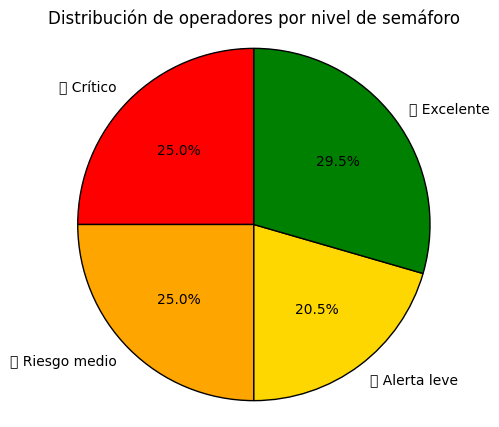

In [ ]:
# Gráfico de operadores por nivel de semáforo

# Datos
labels = ['🔴 Crítico', '🟠 Riesgo medio', '🟡 Alerta leve', '🟢 Excelente']
sizes = [273, 273, 224, 322]
colors = ['red', 'orange', 'gold', 'green']

plt.figure(figsize=(5,5))

# Gráfico de torta
plt.pie(
    sizes,
    labels=labels,
    colors=colors,
    autopct='%1.1f%%',  # 👈 muestra porcentaje
    startangle=90,
    wedgeprops={'edgecolor': 'black'}
)

# Título
plt.title('Distribución de operadores por nivel de semáforo')

plt.axis('equal')  # 👈 hace el círculo perfecto

plt.show()

In [ ]:
#a. Tasa de llamadas perdidas
lost_rate_operator = tipicos.groupby('operator_id')['is_missed_call'].mean()
lost_rate_operator.sort_values(ascending=False).head(10)

operator_id
919162    1.0
919188    1.0
919192    1.0
919200    1.0
919202    1.0
962904    1.0
914626    1.0
919374    1.0
919376    1.0
919198    1.0
Name: is_missed_call, dtype: float64

In [ ]:
# 
# 1️⃣ Calcular duración promedio por operador
avg_duration_operator = tipicos.groupby('operator_id')['call_duration_min'].mean()

# 2️⃣ Calcular duración promedio general (mediana de promedios)
avg_duration_general = avg_duration_operator.median()

# 3️⃣ Mostrar resultado
print("Duración promedio general por operador (min):", round(avg_duration_general, 2))

Duración promedio general por operador (min): 2.9


4.5 Segmentación 

remitirse al Semáforo de niveles de productividad y cumplimiento por operador en donde se muestra la clasificación por niveles de eficiencia.

4.6 Identificación de patrones

4.7 Cruces operador - cliente


c:\Users\mateg\AppData\Local\Programs\Python\Python311\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


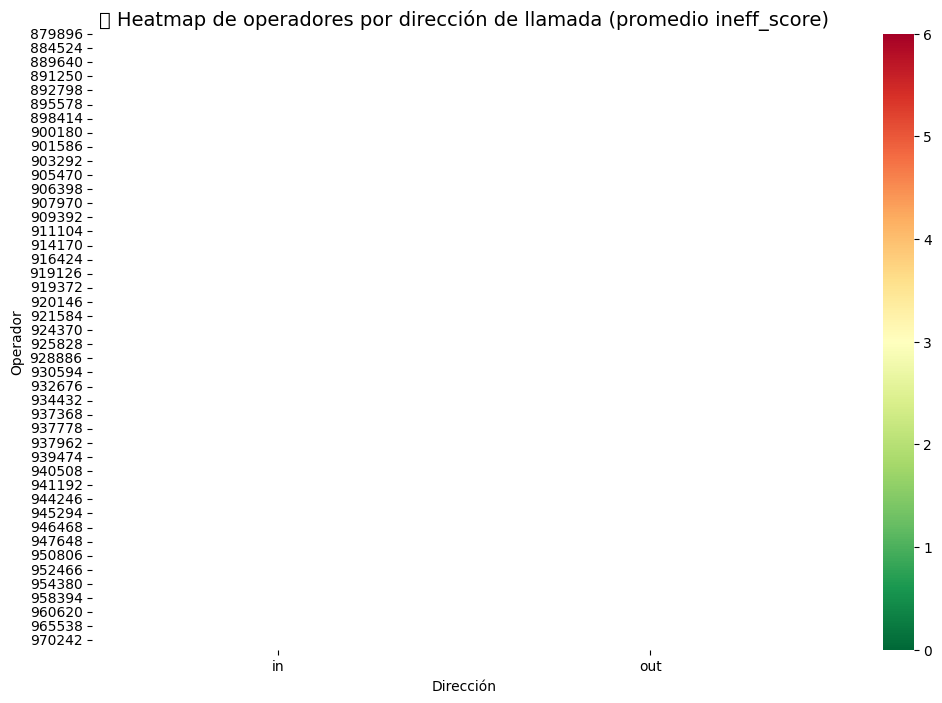

In [ ]:

# Agrupar promedio de ineff_score por operador y dirección de llamada
pivot = tipicos.groupby(['operator_id', 'direction'])['ineff_score'].mean().reset_index()

# Pivotar usando argumentos nombrados
pivot_table = pivot.pivot(index='operator_id', columns='direction', values='ineff_score').fillna(0)

# Graficar heatmap
plt.figure(figsize=(12,8))
sns.heatmap(pivot_table, cmap='RdYlGn_r', linewidths=0.5)
plt.title("📊 Heatmap de operadores por dirección de llamada (promedio ineff_score)", fontsize=14)
plt.xlabel("Dirección")
plt.ylabel("Operador")
plt.show()

C:\Users\mateg\AppData\Local\Temp\ipykernel_17660\1354490145.py:26: UserWarning: Glyph 128992 (\N{LARGE ORANGE CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\mateg\AppData\Local\Temp\ipykernel_17660\1354490145.py:26: UserWarning: Glyph 128993 (\N{LARGE YELLOW CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\mateg\AppData\Local\Temp\ipykernel_17660\1354490145.py:26: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\mateg\AppData\Local\Temp\ipykernel_17660\1354490145.py:26: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\mateg\AppData\Local\Programs\Python\Python311\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128992 (\N{LARGE ORANGE CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\mateg\AppData\Local\Programs\Python\Python311\Lib\site-package

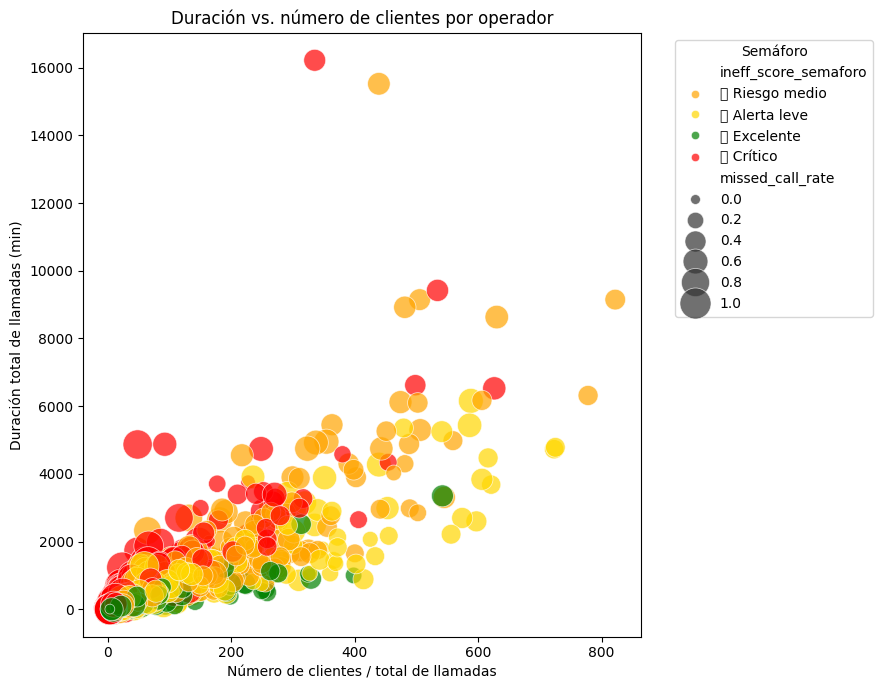

In [ ]:

# Mapear colores del semáforo dinámico
color_map = {
    '🔴 Crítico': 'red',
    '🟠 Riesgo medio': 'orange',
    '🟡 Alerta leve': 'gold',
    '🟢 Excelente': 'green'
}

plt.figure(figsize=(9,7))

sns.scatterplot(
    data=operador_summary_tipicos,
    x='total_calls',                # número de clientes/llamadas por operador
    y='total_duration',             # duración promedio o total de llamadas
    size='missed_call_rate',        # tamaño del punto según llamadas perdidas
    hue='ineff_score_semaforo',     # color según semáforo dinámico
    palette=color_map,
    sizes=(50, 500),
    alpha=0.7
)

plt.title("Duración vs. número de clientes por operador")
plt.xlabel("Número de clientes / total de llamadas")
plt.ylabel("Duración total de llamadas (min)")
plt.legend(title='Semáforo', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

Paso 5 Análisis de Negocio

5.1 Detectar factores que influyen en el comportamiento del cliente

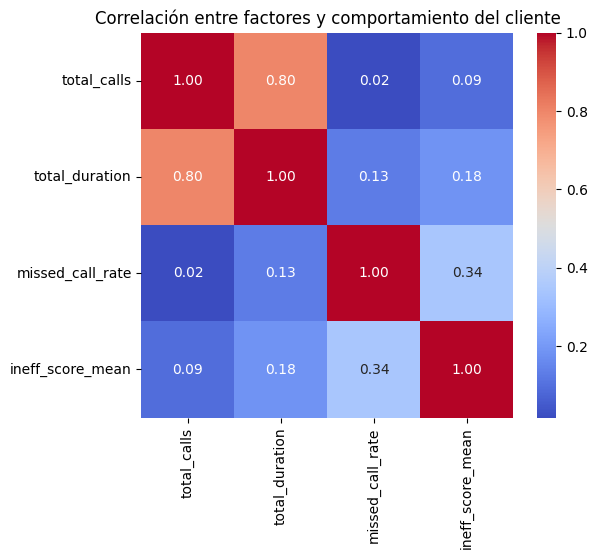

In [ ]:

# Seleccionar variables relevantes que sí están en tu DataFrame
vars_corr = operador_summary_tipicos[['total_calls','total_duration','missed_call_rate','ineff_score_mean']]

# Matriz de correlación
corr = vars_corr.corr()

# Heatmap
plt.figure(figsize=(6,5))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlación entre factores y comportamiento del cliente")
plt.show()

5.3 Prueba de hipótesis

In [ ]:
# Prueba z-test de proporciones

# Conteos
missed_in = tipicos[tipicos['direction'] == 'in']['is_missed_call'].sum()
total_in = tipicos[tipicos['direction'] == 'in']['is_missed_call'].count()

missed_out = tipicos[tipicos['direction'] == 'out']['is_missed_call'].sum()
total_out = tipicos[tipicos['direction'] == 'out']['is_missed_call'].count()

# Datos para la prueba
count = [missed_out, missed_in]
nobs = [total_out, total_in]

# Test (one-sided: out > in)
stat, pval = proportions_ztest(count, nobs, alternative='larger')

print(f"Z-stat: {stat:.3f}, p-value: {pval:.5f}")

if pval < 0.05:
    print("✅ Las llamadas salientes tienen una tasa de pérdida significativamente mayor")
else:
    print("❌ No hay evidencia suficiente de diferencia significativa")

Z-stat: 39.438, p-value: 0.00000
✅ Las llamadas salientes tienen una tasa de pérdida significativamente mayor
